# 01 — Data Exploration

**Goal:** Understand the raw collected data — its structure, quality, and quirks — before any cleaning or transformation.


In [191]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

## 1. Load Raw JSON Files

Each article is stored as a separate `.json` file under `data/raw/<date>/`.
We walk through all date folders and load every article into a flat list, then convert to a DataFrame.

In [192]:
DATA_DIR = "../data/raw"

records = []
for date_folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, date_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            filepath = os.path.join(folder_path, filename)
            with open(filepath, encoding="utf-8") as f:
                records.append(json.load(f))

df = pd.DataFrame(records)
df["published_at_dt"] = pd.to_datetime(df["published_at"], format="ISO8601", utc=True)
print(f"Total articles loaded: {len(df)}")

Total articles loaded: 29027


## 2. Basic Structure Overview

In [193]:
df.head(3)

,source,title,url,published_at,summary,full_text,fetched_at,published_at_dt
0,segabg,Правят се важни промени при шофьорските курсове,https://www.segabg.com/hot/category-consult/pr...,2026-03-10T04:05:33+00:00,Министерство на транспорта прави поредни и то ...,Министерство на транспорта прави поредни и то ...,2026-05-04T19:45:07.876366+00:00,2026-03-10 04:05:33+00:00
1,segabg,МВР променя правилата за колите на починалите,https://www.segabg.com/hot/category-consult/mv...,2026-03-31T17:26:59+00:00,"МВР предупреди, че от от 31 март т. г. започва...","МВР предупреди, че от от 31 март т.г. започва ...",2026-05-04T19:45:07.876356+00:00,2026-03-31 17:26:59+00:00
2,segabg,Сделките с имоти драстично спаднаха през първо...,https://www.segabg.com/hot/sdelkite-imoti-dras...,2026-04-12T03:24:43+00:00,Прогнозите за охлаждане на пазара на недвижими...,Прогнозите за охлаждане на пазара на недвижими...,2026-05-04T19:45:07.876310+00:00,2026-04-12 03:24:43+00:00


In [194]:
print(f"Shape: {df.shape}")

Shape: (29027, 8)


In [195]:
print(f"\nColumns: {df.columns.tolist()}")


Columns: ['source', 'title', 'url', 'published_at', 'summary', 'full_text', 'fetched_at', 'published_at_dt']


In [196]:
print(f"\nData types:\n{df.dtypes}")


Data types:
source                             str
title                              str
url                                str
published_at                       str
summary                            str
full_text                          str
fetched_at                         str
published_at_dt    datetime64[us, UTC]
dtype: object


## 3. Articles per Source

In [197]:
source_counts = df["source"].value_counts().sort_values(ascending=False)
source_counts

source
24chasa         7048
monitor         4900
fakti           4219
actualno        4144
nova            2649
bta             1630
standartnews    1334
vesti           1100
segabg           616
blitz            531
banker           403
dnevnik          256
economic         167
capital           30
Name: count, dtype: int64

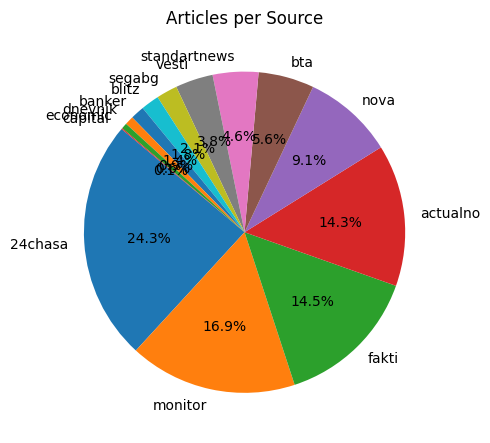

In [198]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    source_counts.values,
    labels=source_counts.index,
    autopct="%1.1f%%",
    startangle=140,
)
ax.set_title("Articles per Source")
plt.tight_layout()
plt.show()

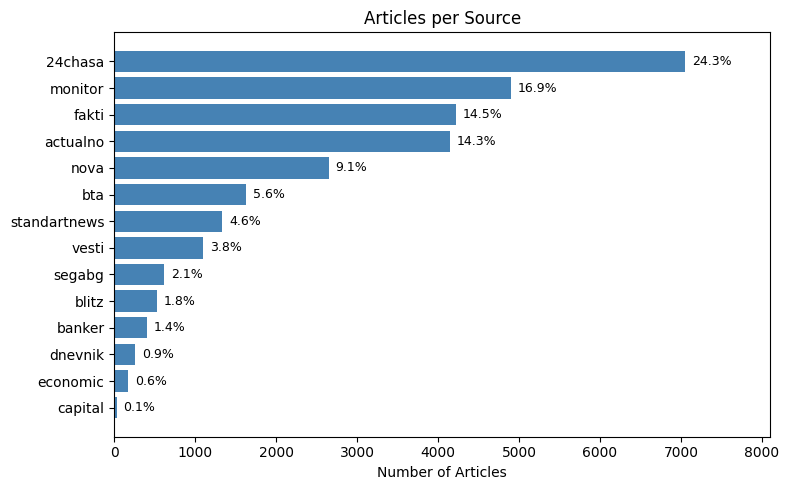

In [199]:
total = source_counts.sum()
pct = (source_counts / total * 100).round(1)
labels = [f"{pct[s]}%" for s in source_counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(source_counts.index[::-1], source_counts.values[::-1], color="steelblue")
ax.set_title("Articles per Source")
ax.set_xlabel("Number of Articles")
ax.bar_label(bars, labels=labels[::-1], padding=5, fontsize=9)
ax.set_xlim(0, source_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## 4. Temporal Coverage

Check the date range of collected articles and whether collection has been consistent over time.

In [200]:
print(f"Oldest  : {df['published_at_dt'].min()}")
print(f"Newest  : {df['published_at_dt'].max()}")
print(
    f"Days covered: {(df['published_at_dt'].max() - df['published_at_dt'].min()).days}"
)

Oldest  : 2026-03-10 04:05:33+00:00
Newest  : 2026-05-16 03:25:57.118441+00:00
Days covered: 66


In [201]:
earliest = (
    df.groupby("source")
    .agg(
        earliest_published=("published_at_dt", "min"),
        earliest_fetched=("fetched_at", "min"),
    )
    .sort_values("earliest_published")
)

earliest["published_at_dt"] = pd.to_datetime(earliest["earliest_published"]).dt.date
earliest["fetched_at"] = pd.to_datetime(earliest["earliest_fetched"]).dt.date
earliest["days_backfill"] = (
    pd.to_datetime(earliest["earliest_fetched"]).dt.tz_localize(None)
    - pd.to_datetime(earliest["earliest_published"]).dt.tz_localize(None)
).dt.days

print(earliest[["earliest_published", "earliest_fetched", "days_backfill"]].to_string())

                           earliest_published                  earliest_fetched  days_backfill
source                                                                                        
segabg              2026-03-10 04:05:33+00:00  2026-05-04T19:45:07.875620+00:00             55
nova                2026-04-19 21:02:57+00:00  2026-04-20T20:53:13.448140+00:00              0
24chasa             2026-04-20 11:34:00+00:00  2026-04-20T19:17:57.301914+00:00              0
actualno            2026-04-20 12:36:00+00:00  2026-04-20T19:20:20.997203+00:00              0
blitz               2026-04-20 15:25:00+00:00  2026-04-20T19:20:59.930288+00:00              0
fakti               2026-04-20 15:45:46+00:00  2026-04-20T19:17:32.119362+00:00              0
capital             2026-04-21 09:55:00+00:00  2026-04-22T19:23:07.081987+00:00              1
dnevnik             2026-04-22 13:23:00+00:00  2026-04-22T19:22:56.582424+00:00              0
economic            2026-05-03 09:00:10+00:00  202

### 4a. Segabg — RSS Backfill Investigation

In [202]:
segabg_df = df[df["source"] == "segabg"].copy()
segabg_df["fetched_at_dt"] = pd.to_datetime(segabg_df["fetched_at"])
segabg_df["fetch_round"] = segabg_df["fetched_at_dt"].dt.floor("2h")

per_fetch = segabg_df.groupby("fetch_round").size().sort_index()
print(f"Number of fetches: {len(per_fetch)}")
print(per_fetch.to_string())

Number of fetches: 85
fetch_round
2026-05-04 18:00:00+00:00    74
2026-05-04 20:00:00+00:00     2
2026-05-04 22:00:00+00:00     1
2026-05-05 02:00:00+00:00     1
2026-05-05 06:00:00+00:00    11
2026-05-05 10:00:00+00:00     8
2026-05-05 14:00:00+00:00    20
2026-05-05 16:00:00+00:00     7
2026-05-05 18:00:00+00:00     4
2026-05-05 20:00:00+00:00     4
2026-05-05 22:00:00+00:00     1
2026-05-06 02:00:00+00:00     3
2026-05-06 06:00:00+00:00     7
2026-05-06 10:00:00+00:00    11
2026-05-06 14:00:00+00:00     5
2026-05-06 16:00:00+00:00     8
2026-05-06 18:00:00+00:00     5
2026-05-06 20:00:00+00:00     1
2026-05-06 22:00:00+00:00     1
2026-05-07 06:00:00+00:00     7
2026-05-07 10:00:00+00:00     8
2026-05-07 14:00:00+00:00    14
2026-05-07 16:00:00+00:00     9
2026-05-07 22:00:00+00:00     2
2026-05-08 06:00:00+00:00    16
2026-05-08 08:00:00+00:00     7
2026-05-08 10:00:00+00:00     9
2026-05-08 12:00:00+00:00     8
2026-05-08 14:00:00+00:00     6
2026-05-08 16:00:00+00:00     5
2026-0

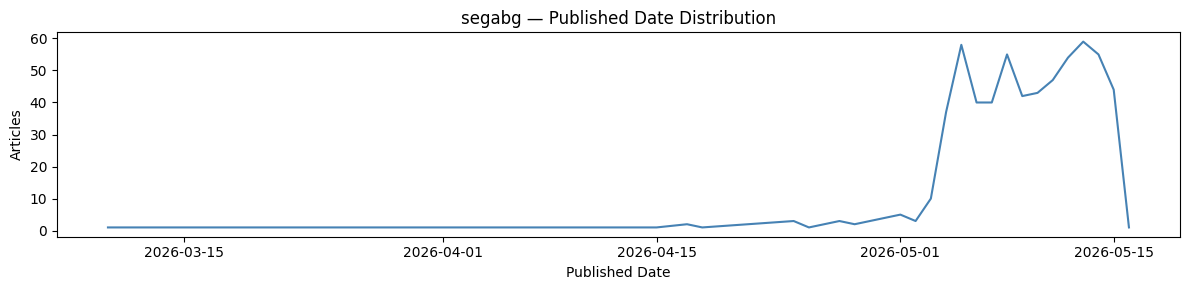

In [203]:
fig, ax = plt.subplots(figsize=(12, 3))
segabg_df["published_at_dt"].dt.date.value_counts().sort_index().plot(
    ax=ax, color="steelblue"
)
ax.set_title("segabg — Published Date Distribution")
ax.set_xlabel("Published Date")
ax.set_ylabel("Articles")
plt.tight_layout()
plt.show()

**Finding:** Segabg was added as a source on 2026-05-04. Its first fetch returned 74 articles in a single run, spanning back to 2026-03-10 — 55 days of backfill. All other sources showed 0 days backfill at first fetch. Subsequent segabg fetches return 1–20 articles, which is normal.

This is a one-time RSS backlog dump that inflates "days covered" from ~18 to 59 days and skews temporal analysis.

**Decision:** Drop segabg articles published before 2026-04-20 (the collection start date).

In [204]:
COLLECTION_START = pd.Timestamp("2026-04-20", tz="UTC")

backfill_mask = (df["source"] == "segabg") & (df["published_at_dt"] < COLLECTION_START)
print(
    f"Dropping {backfill_mask.sum()} segabg articles published before {COLLECTION_START.date()}"
)
df = df[~backfill_mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 7 segabg articles published before 2026-04-20
Remaining articles: 29020


In [205]:
print(f"Oldest  : {df['published_at_dt'].min()}")
print(f"Newest  : {df['published_at_dt'].max()}")
print(
    f"Days covered: {(df['published_at_dt'].max() - df['published_at_dt'].min()).days}"
)

Oldest  : 2026-04-19 21:02:57+00:00
Newest  : 2026-05-16 03:25:57.118441+00:00
Days covered: 26


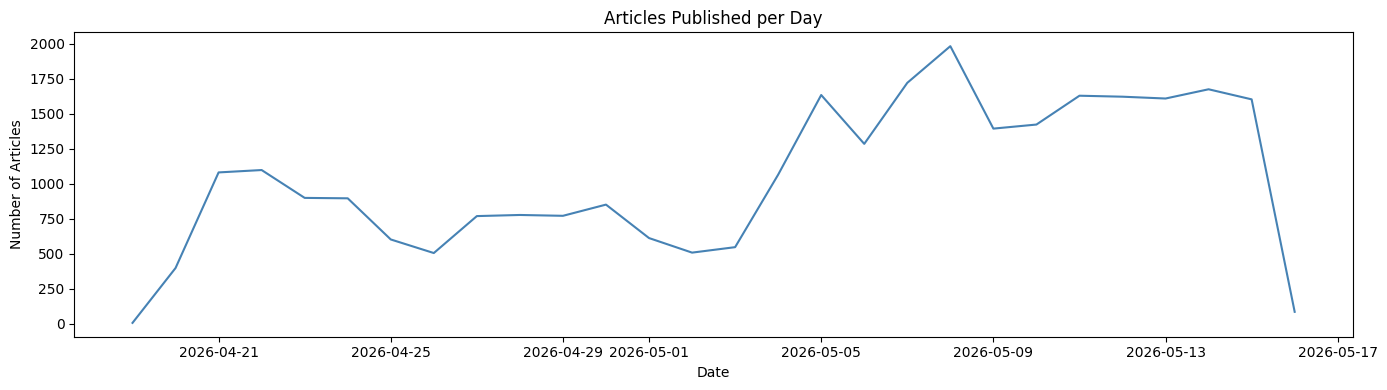

In [206]:
articles_per_day = df.groupby(df["published_at_dt"].dt.date).size()

fig, ax = plt.subplots(figsize=(14, 4))
articles_per_day.plot(ax=ax, color="steelblue")
ax.set_title("Articles Published per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Articles")
plt.tight_layout()
plt.show()

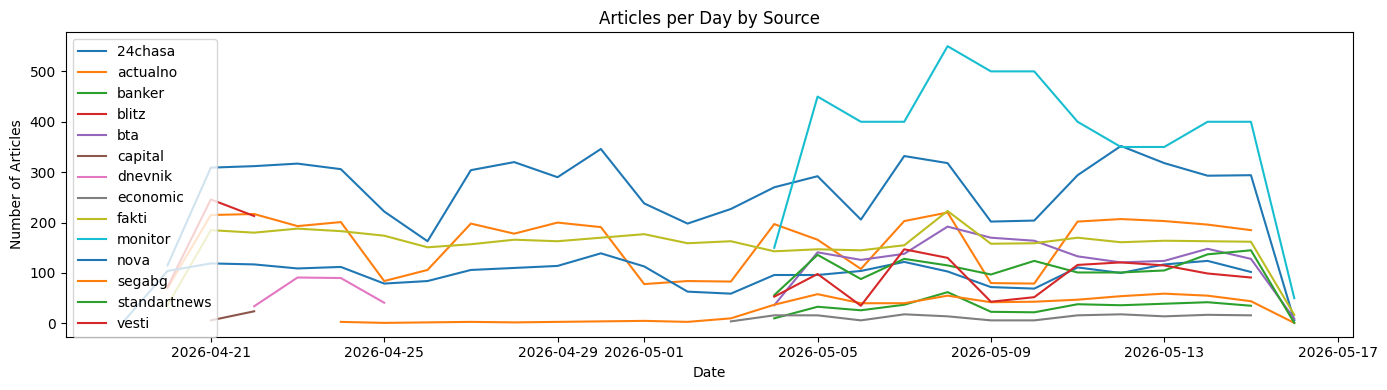

In [207]:
fig, ax = plt.subplots(figsize=(14, 4))
for source, group in df.groupby("source"):
    daily = group.groupby(group["published_at_dt"].dt.date).size()
    daily.plot(ax=ax, label=source)
ax.set_title("Articles per Day by Source")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Articles")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Missing & Empty Value Analysis

In [208]:
missing_summary = pd.DataFrame(
    {
        "null": df.isnull().sum(),
        "empty": (df == "").sum(),
        "whitespace_only": df.apply(
            lambda col: (col.str.strip() == "").sum() if col.dtype == "object" else 0
        )
        - (df == "").sum(),
        "total_missing": df.isnull().sum() + (df == "").sum(),
    }
)
missing_summary["%_missing"] = (missing_summary["total_missing"] / len(df) * 100).round(
    1
)
missing_summary

,null,empty,whitespace_only,total_missing,%_missing
source,0,0,0,0,0.0
title,0,0,0,0,0.0
url,0,0,0,0,0.0
published_at,0,0,0,0,0.0
summary,0,74,-74,74,0.3
full_text,0,567,-567,567,2.0
fetched_at,0,0,0,0,0.0
published_at_dt,0,0,0,0,0.0


In [209]:
print("Empty full_text per source:")
print(df[df["full_text"] == ""]["source"].value_counts())

Empty full_text per source:
source
blitz      530
capital     30
monitor      4
fakti        2
24chasa      1
Name: count, dtype: int64


In [210]:
print("Empty summary per source:")
print(df[df["summary"] == ""]["source"].value_counts())

Empty summary per source:
source
vesti     65
segabg     9
Name: count, dtype: int64


In [211]:
empty_summary_sources = df[df["summary"] == ""]
empty_summary_sources.head()

,source,title,url,published_at,summary,full_text,fetched_at,published_at_dt
3749,segabg,ОБЯВА ЗА ТЪРГ С ТАЙНО НАДДАВАНЕ,https://www.segabg.com/category-imoti/obyava-z...,2026-04-24T11:11:30+00:00,,ДЪРЖАВЕН САТИРИЧЕН ТЕАТЪР „АЛЕКО КОНСТАНТИНОВ“...,2026-05-04T19:45:07.876283+00:00,2026-04-24 11:11:30+00:00
10581,vesti,Експлозия и пожар на южнокорейски кораб в Орму...,https://www.vesti.bg/sviat/eksploziia-i-pozhar...,2026-05-04T15:04:00+00:00,,"В ластите в Южна Корея съобщиха, че „експлозия...",2026-05-04T19:45:45.710489+00:00,2026-05-04 15:04:00+00:00
10710,vesti,Кремъл засилва сигурността около Путин на фона...,https://www.vesti.bg/sviat/kremyl-zasilva-sigu...,2026-05-04T10:51:00+00:00,,К ремъл значително е засилил личната охрана на...,2026-05-04T19:45:45.710719+00:00,2026-05-04 10:51:00+00:00
10838,vesti,Сериалът „Взимай парите и бягай“ за Ружа Игнат...,https://www.vesti.bg/lyubopitno/serialyt-vzima...,2026-05-04T13:13:00+00:00,,Н овият минисериал „Взимай парите и бягай“ (Ta...,2026-05-04T19:45:45.710547+00:00,2026-05-04 13:13:00+00:00
11152,vesti,"Българка падна от 20 метра в Гърция, в критичн...",https://www.vesti.bg/sviat/bylgarka-padna-ot-2...,2026-05-04T11:37:00+00:00,,"Б ългарка на 64 години е в критично състояние,...",2026-05-04T19:45:45.710665+00:00,2026-05-04 11:37:00+00:00


### 5a. Blitz & Capital — Empty `full_text`

In [212]:
# Confirm how many blitz/capital articles have content
for source in ["blitz", "capital"]:
    if source not in df["source"].values:
        print(f"{source}: not in dataset")
        continue
    total_s = len(df[df["source"] == source])
    non_empty = len(df[(df["source"] == source) & (df["full_text"] != "")])
    print(
        f"{source}: {total_s} total, {non_empty} with full_text ({total_s - non_empty} empty)"
    )

blitz: 531 total, 1 with full_text (530 empty)
capital: 30 total, 0 with full_text (30 empty)


In [213]:
# Inspect a blitz article HTML to understand why extraction failed
if "blitz" in df["source"].values:
    blitz_url = df[df["source"] == "blitz"]["url"].iloc[0]
    print(f"Testing URL: {blitz_url}")

    import requests

    HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; NewsBot/1.0)"}
    r = requests.get(blitz_url, timeout=10, headers=HEADERS)
    soup = BeautifulSoup(r.text, "html.parser")

    print(f"Status: {r.status_code} | Page length: {len(r.text)} chars")
    print()

    for tag in ["article", "main"]:
        found = soup.find(tag)
        print(f"<{tag}>: {'FOUND' if found else 'NOT FOUND'}")

    print()
    for div in soup.find_all("div", class_=True):
        classes = " ".join(div.get("class", []))
        text_len = len(div.get_text(strip=True))
        if text_len > 200:
            print(f"div.{classes[:60]}: {text_len} chars")

Testing URL: https://blitz.bg/voinite/tramp-posochi-denya-v-koyto-shte-podpishe-mir-s-iran_news1147877.html
Status: 200 | Page length: 156880 chars

<article>: FOUND
<main>: FOUND

div.container: 643 chars
div.container: 405 chars
div.row: 405 chars
div.col-12 nav-container: 405 chars
div.container container-col: 9929 chars
div.left-col: 7618 chars
div.article-content: 5631 chars
div.row: 231 chars
div.section-body: 580 chars
div.more-from-topic-slider: 580 chars
div.section-body: 478 chars
div.row: 478 chars
div.theiaStickySidebar: 2311 chars
div.section-body: 420 chars
div.row: 420 chars
div.col-12: 234 chars
div.weather-widget: 744 chars
div.tab-content: 1116 chars
div.tab-pane fade show active: 541 chars
div.tab-pane fade show: 575 chars
div.container: 953 chars
div.row: 953 chars
div.col-12 col-md-7: 586 chars
div.d-flex flex-column: 586 chars


**Finding:** Blitz and Capital return valid HTTP 200 responses locally but GitHub Actions is blocked by those sites.
The one non-empty blitz article was likely fetched before the block kicked in.

**Decision:** 
- Dropping records from both `blitz` and `capital` sources and also the one record with empty `full_text` from `24chasa`
- Will keep records with empty `summary` for now, because their `full_text` column is not empty

In [214]:
sources = ["blitz", "capital"]
mask = df["source"].isin(sources)

print(f"Dropping {mask.sum()} articles from sources: {sources}")
df = df[~mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 561 articles from sources: ['blitz', 'capital']
Remaining articles: 28459


In [215]:
mask = df["full_text"].isna() | (df["full_text"].str.strip() == "")

print(f"Dropping {mask.sum()} articles with empty full_text")
df = df[~mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 7 articles with empty full_text
Remaining articles: 28452


## 6. Text Length Distribution

In [216]:
df["word_count"] = df["full_text"].fillna("").apply(lambda x: len(x.split()))
print(df["word_count"].describe().round(0))

count    28452.0
mean       388.0
std        515.0
min         13.0
25%        173.0
50%        274.0
75%        434.0
max      13773.0
Name: word_count, dtype: float64


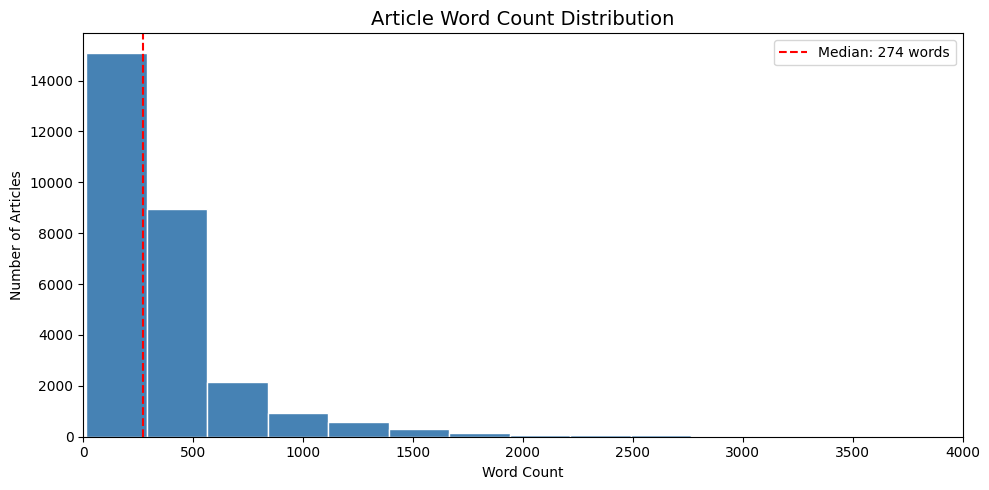

In [217]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["word_count"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("Article Word Count Distribution", fontsize=14)
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Articles")
ax.axvline(
    df["word_count"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df['word_count'].median():.0f} words",
)
ax.legend()
ax.set_xlim(0, 4000)
plt.tight_layout()
plt.show()

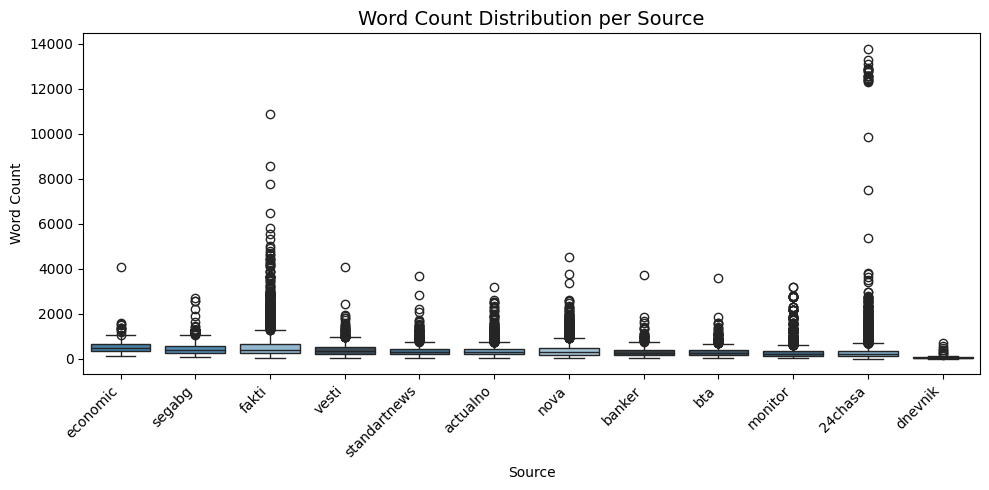

In [218]:
fig, ax = plt.subplots(figsize=(10, 5))
sources_ordered = (
    df.groupby("source")["word_count"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df,
    x="source",
    y="word_count",
    order=sources_ordered,
    palette="Blues_d",
    ax=ax,
    hue="source",
    legend=False,
)
ax.set_title("Word Count Distribution per Source", fontsize=14)
ax.set_xlabel("Source")
ax.set_ylabel("Word Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [219]:
summary_stats = (
    df.groupby("source")["word_count"]
    .agg(["min", "max", "mean", "median", "count"])
    .round(0)
    .sort_values("median", ascending=False)
)
print(summary_stats)

              min    max   mean  median  count
source                                        
economic      130   4092  567.0   478.0    167
segabg         85   2696  477.0   384.0    609
fakti          47  10868  579.0   383.0   4217
vesti          53   4081  407.0   340.0   1100
standartnews   40   3687  364.0   306.0   1334
actualno       39   3203  370.0   305.0   4144
nova           45   4502  456.0   303.0   2649
banker         43   3714  351.0   267.0    403
bta            36   3576  312.0   265.0   1630
monitor        35   3173  292.0   225.0   4896
24chasa        13  13773  346.0   213.0   7047
dnevnik        13    701   55.0    23.0    256


## 10. Duplicate Detection

Two types of duplicates to check:
- **Same-source duplicates**: same article fetched in multiple 2-hour collection windows
- **Near-duplicates**: same URL with slightly different content (edited articles)

In [220]:
url_counts = df["url"].value_counts()
duplicate_urls = url_counts[url_counts > 1]

print(f"Total articles  : {len(df)}")
print(f"Unique URLs     : {df['url'].nunique()}")
print(f"Duplicate URLs  : {len(duplicate_urls)}")
print(
    f"Excess rows     : {(url_counts - 1).clip(lower=0).sum()} (rows that are duplicates)"
)

Total articles  : 28452
Unique URLs     : 24485
Duplicate URLs  : 1185
Excess rows     : 3967 (rows that are duplicates)


In [221]:
duplicates_df = df[df["url"].isin(duplicate_urls.index)].copy()

print("Duplicate articles per source:")
print(duplicates_df["source"].value_counts())

Duplicate articles per source:
source
monitor         4844
segabg           130
fakti             76
24chasa           53
actualno          19
bta               14
nova              10
dnevnik            2
vesti              2
standartnews       2
Name: count, dtype: int64


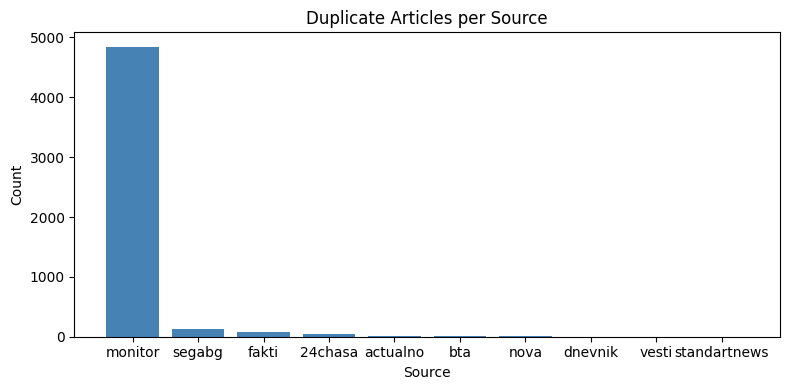

In [222]:
fig, ax = plt.subplots(figsize=(8, 4))

dup_per_source = duplicates_df["source"].value_counts()
ax.bar(dup_per_source.index, dup_per_source.values, color="steelblue")
ax.set_title("Duplicate Articles per Source")
ax.set_xlabel("Source")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

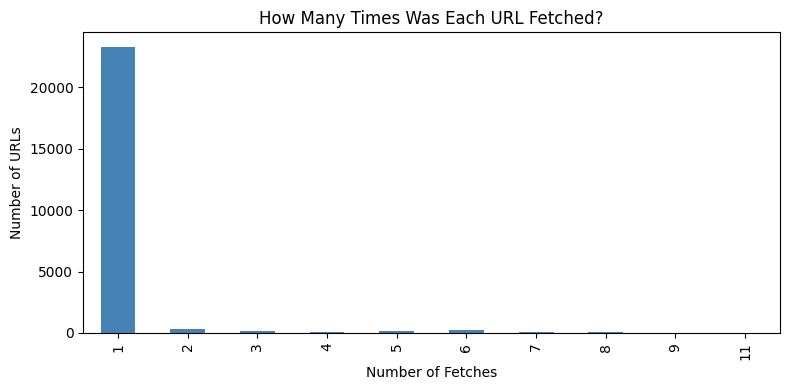

In [223]:
fig, ax = plt.subplots(figsize=(8, 4))

url_counts.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("How Many Times Was Each URL Fetched?")
ax.set_xlabel("Number of Fetches")
ax.set_ylabel("Number of URLs")

plt.tight_layout()
plt.show()

In [224]:
# Investigate: are duplicated articles identical or edited between fetches?
sample_dup_url = duplicate_urls.index[0]
versions = df[df["url"] == sample_dup_url][
    ["source", "title", "fetched_at", "full_text"]
]
print(f"URL: {sample_dup_url}")
print(f"Fetched {len(versions)} times")
print()
for i, (_, row) in enumerate(versions.iterrows()):
    print(f"Version {i+1} — fetched at {row['fetched_at']}")
    print(f"Text preview: {str(row['full_text'])[:300]}")
    print()

URL: https://www.segabg.com/category-sport/purva-liga-xxxiii-krug-rezultati-i-klasirane-video-reportazhi-0
Fetched 11 times

Version 1 — fetched at 2026-05-05T19:25:40.174230+00:00
Text preview: Първа група
8 май (петък)
"ЦСКА 1948" - ЦСКА 20:00 ч.
(по Диема спорт)
9 май (събота)
"Левски" - "Лудогорец" 18:45 ч.
(по Диема спорт)
КЛАСИРАНЕ | ||||||
| М | П | Р | З | ГР | Т | |
1. "Левски" |
32 |
24 |
4 |
4 |
68:23 |
76 |
2. "ЦСКА 1948" |
32 |
19 |
5 |
8 |
52:33 |
62 |
3. "Лудогорец" |
32 |
17

Version 2 — fetched at 2026-05-06T19:50:18.277093+00:00
Text preview: Първа група
8 май (петък)
"ЦСКА 1948" - ЦСКА 20:00 ч.
(по Диема спорт)
9 май (събота)
"Левски" - "Лудогорец" 18:45 ч.
(по Диема спорт)
КЛАСИРАНЕ | ||||||
| М | П | Р | З | ГР | Т | |
1. "Левски" |
32 |
24 |
4 |
4 |
68:23 |
76 |
2. "ЦСКА 1948" |
32 |
19 |
5 |
8 |
52:33 |
62 |
3. "Лудогорец" |
32 |
17

Version 3 — fetched at 2026-05-06T17:44:10.819265+00:00
Text preview: Първа група
8 май (петък)
"ЦСКА 1948" - ЦСКА 20:00 ч.
(по Дие

Duplicates are concentrated in monitor, with minor contributions from fakti, segabg, and 24chasa.

Inspection of a sample URL fetched many times shows identical full_text across all versions — these are not edited articles but the same article caught in multiple 2-hour collection windows before dropping off the RSS feed.

Decision: Deduplicate by URL, keeping the latest fetched version per URL.

Investigating monitor problem with duplications

In [225]:
monitor_urls = df[df["source"] == "monitor"]["url"]
monitor_dup_urls = monitor_urls[monitor_urls.duplicated(keep=False)]

print(f"Total monitor articles     : {len(monitor_urls)}")
print(f"Unique monitor URLs        : {monitor_urls.nunique()}")
print(f"After dedup (kept)         : {monitor_urls.nunique()}")
print(f"Rows to drop from monitor  : {len(monitor_urls) - monitor_urls.nunique()}")

Total monitor articles     : 4896
Unique monitor URLs        : 1096
After dedup (kept)         : 1096
Rows to drop from monitor  : 3800


In [226]:
monitor_unique = df[df["source"] == "monitor"].drop_duplicates(subset="url")
print(f"Unique articles : {len(monitor_unique)}")
print(
    f"Date range      : {monitor_unique['published_at_dt'].min().date()} → {monitor_unique['published_at_dt'].max().date()}"
)
print(f"Median words    : {monitor_unique['word_count'].median()}")
print("\nPublished per day:")
print(monitor_unique["published_at_dt"].dt.date.value_counts().sort_index().to_string())

Unique articles : 1096
Date range      : 2026-05-04 → 2026-05-16
Median words    : 222.0

Published per day:
published_at_dt
2026-05-04     52
2026-05-05    111
2026-05-06     80
2026-05-07     93
2026-05-08    123
2026-05-09     99
2026-05-10     62
2026-05-11    103
2026-05-12    100
2026-05-13     92
2026-05-14     88
2026-05-15     91
2026-05-16      2


In [227]:
before = len(df)
df = (
    df.sort_values("fetched_at", ascending=False)
    .drop_duplicates(subset="url", keep="first")
    .reset_index(drop=True)
)

print(f"Dropped {before - len(df)} duplicate rows")
print(f"Remaining articles: {len(df)}")

Dropped 3967 duplicate rows
Remaining articles: 24485


## 11. Storing cleaned data in `.parquet` file

In [228]:
out_path = "../data/processed/articles_clean_notebook.parquet"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_parquet(out_path, index=False)
print(f"Saved {len(df)} articles → {out_path}")

Saved 24485 articles → ../data/processed/articles_clean_notebook.parquet


## Summary

**What was done:**
- Loaded all raw JSON articles from date-partitioned folders into a single DataFrame
- Audited the schema, data types, and basic structure
- Analyzed the distribution of articles across sources and visualized temporal coverage
- Identified and removed a historical RSS backfill from one source (`segabg`) that predated the actual collection start — keeping only articles published after collection began
- Detected sources (`blitz`, `capital`) whose article content could not be fetched due to bot-blocking; dropped all records from those sources along with any remaining articles with empty `full_text`
- Analyzed text length (word count) distribution overall and per source
- Detected URL-level duplicates caused by the same article appearing in multiple 2-hour collection windows; verified the content was identical across versions, then deduplicated by keeping the latest fetched copy per URL

**Result:** A deduplicated DataFrame containing only articles with non-empty full text, published within the active collection window, saved to `data/processed/articles_clean.parquet` and ready for cleaning and further analysis.